#8.1 Engine lifetime with RNNs

In this exercise, you will develop a Recurrent Neural Network capable of estimating the lifetime of engines. Your final submission should include a link to your google collab notebook, and a pdf adressing the questions asked in the task.

The paper that can help you with the exercises can be found here:\
Wang, Y., Zhao, Y. & Addepalli, S. Practical Options for Adopting Recurrent Neural Network and Its Variants on Remaining Useful Life Prediction. Chin. J. Mech. Eng. 34, 69 (2021). https://doi.org/10.1186/s10033-021-00588-x

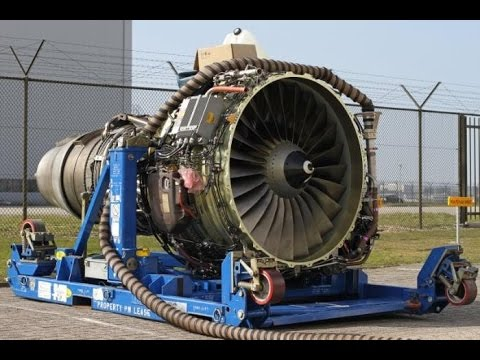



Y. Dwivedi, Predicting Engine Failure using C-MAPSS data, 2018 (https://yajasd.github.io/2018/06/04/Predicting-Engine-Failure/)

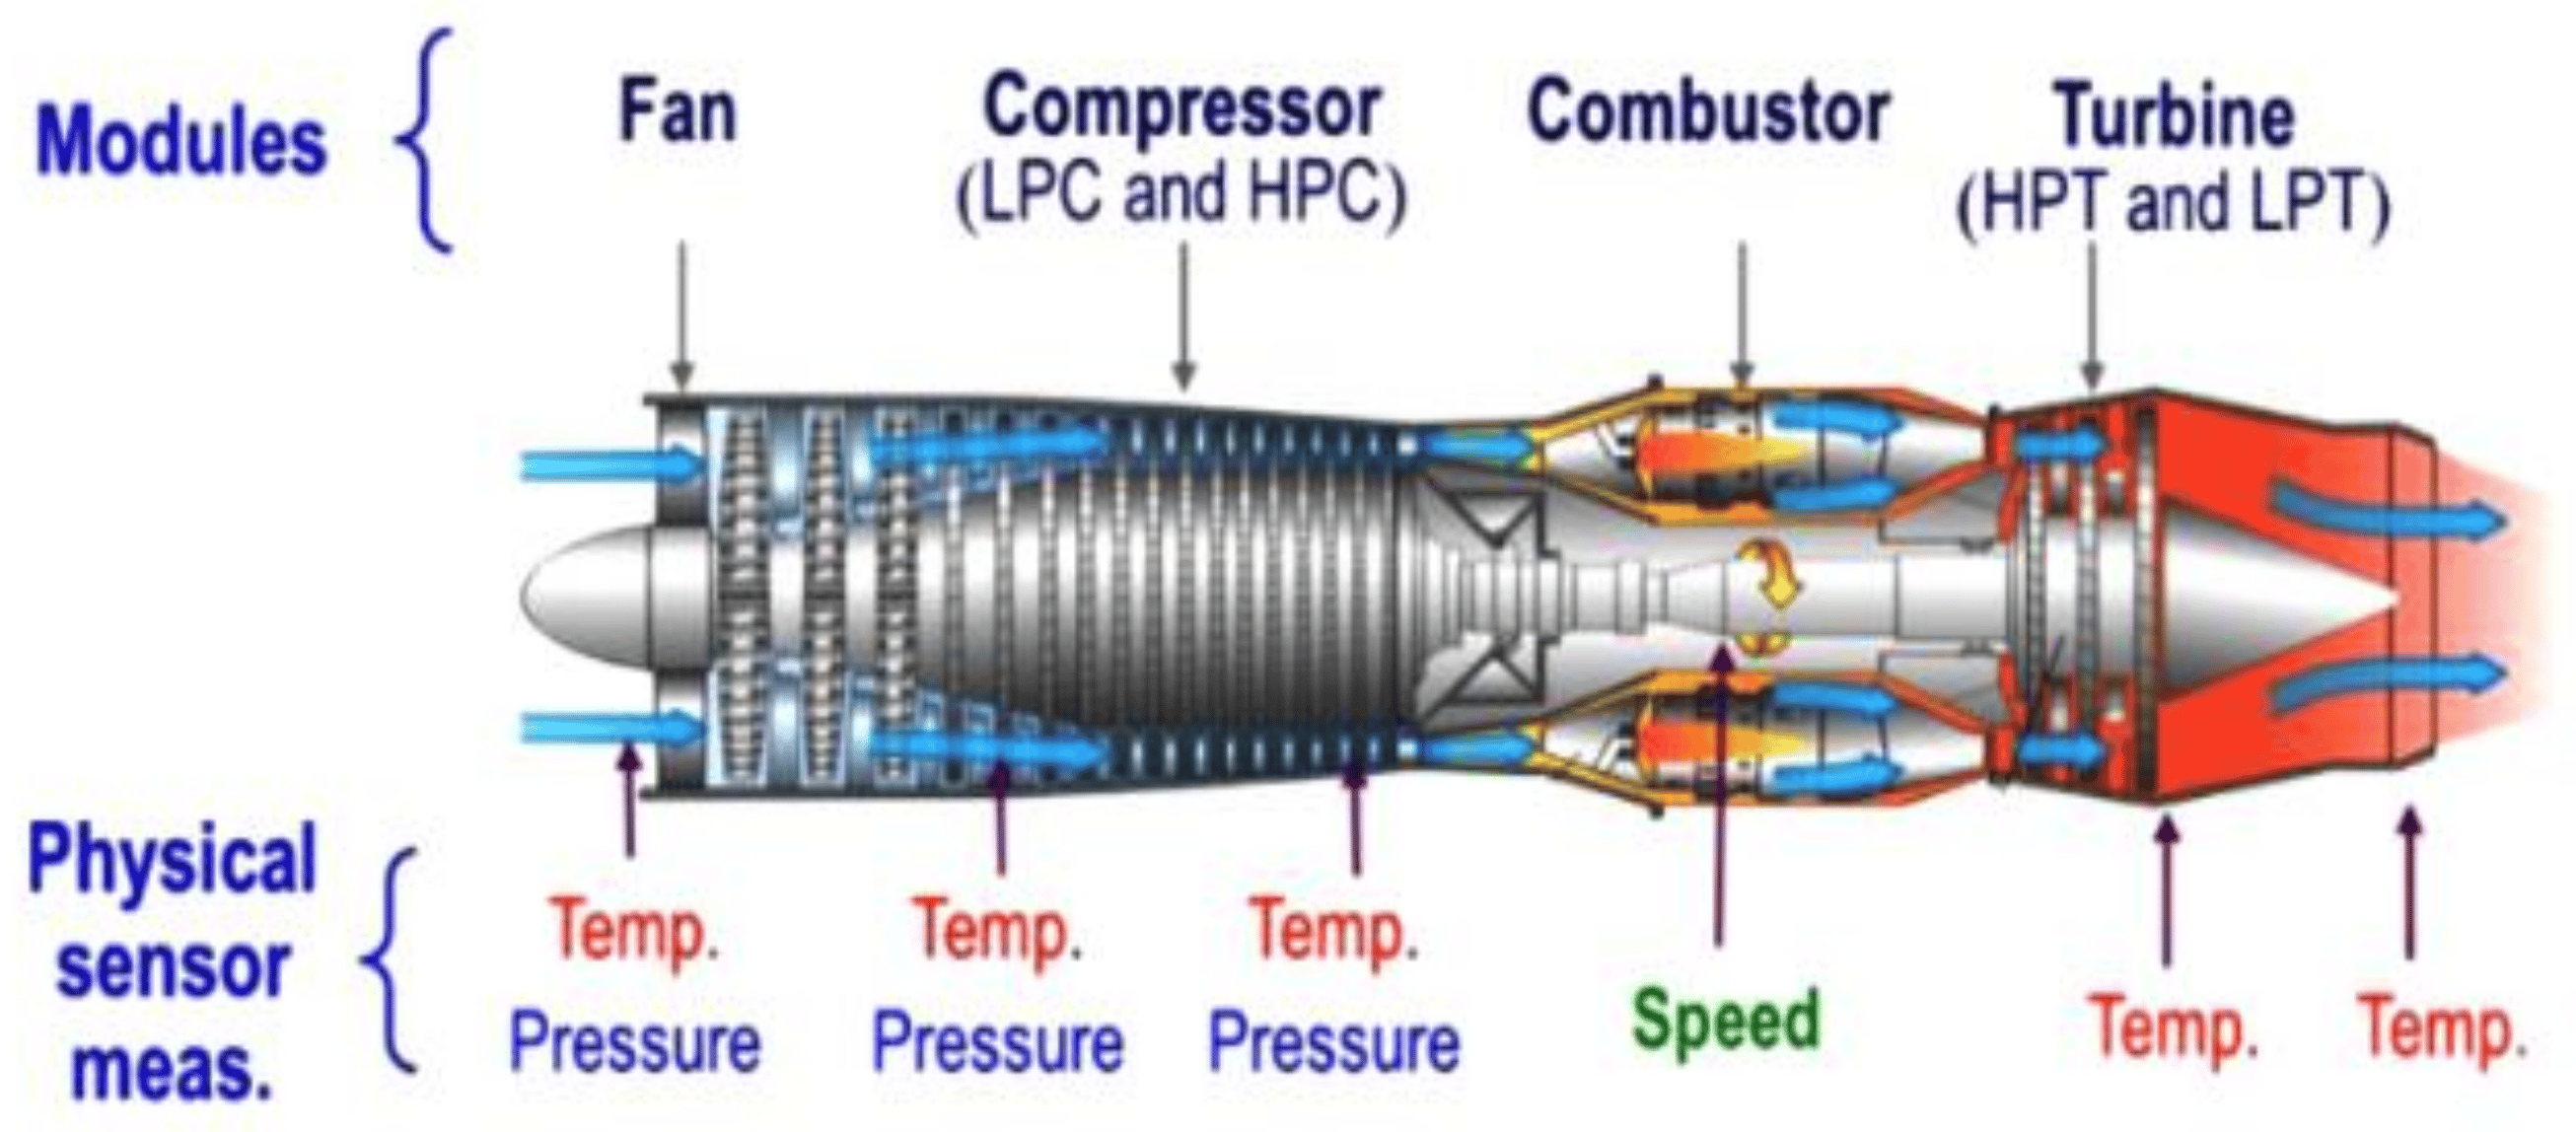


Muneer, A.; Taib, S.M.; Naseer, S.; Ali, R.F.; Aziz, I.A. Data-Driven Deep Learning-Based Attention Mechanism for Remaining Useful Life Prediction: Case Study Application to Turbofan Engine Analysis. Electronics 2021, 10, 2453. https://doi.org/10.3390/electronics10202453

##Experimental Scenario

The goal of this exercise is to develop a model that can predict the remaining lifetime of airplane engines using a recurrent neural network. This exercise shows deep learning apllied to an engineering focused problem where especially the preprocessing of the data is important.

The data consists of multivariate time series of sensor reading and settings from 100 airplane engines, here called *units*. The engines operate normally at the start of each time series, and have been run until they failed. The data is provided in a text file with 26 columns of numbers, separated by spaces. Each column is a different variable and each row represents the setting and sensor values for a given time/cycle, and can hence be seen as a multivariate time series. The columns correspond to:

1\.	unit number\
2\.	time, in cycles\
3\.	operational setting 1\
4\.	operational setting 2\
5\.	operational setting 3\
6\.	sensor measurement  1\
7\.	sensor measurement  2\
... \
26\.	sensor measurement  21

The goal of the exercise is to use an RNN to predict the remaining lifetime of an engine for a certain point in time based on the n_past previous datapoints. The RUL is not given directly in the data files, so we have to calculate it for every time series in the code below. The problem is illustrated in the following figure (showing only one feature):



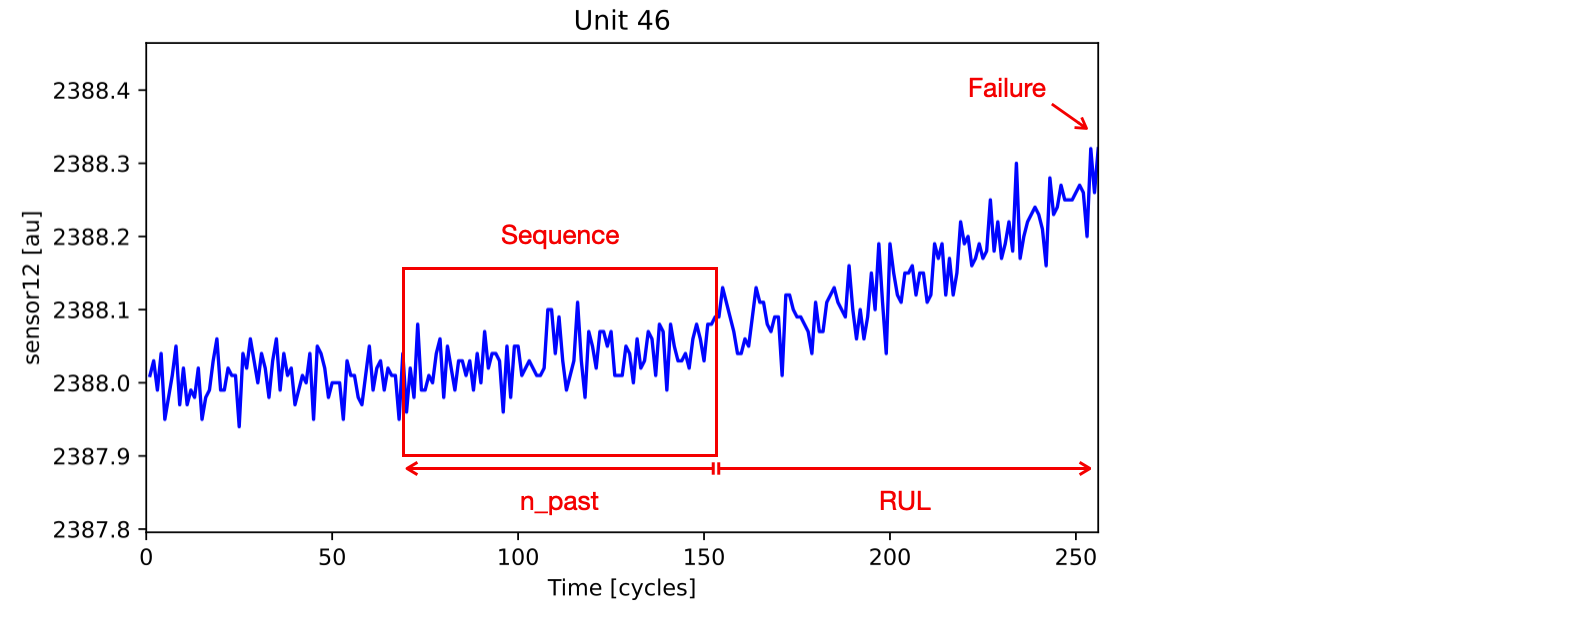

## Tasks


1.   Get familiar with the training data by plotting it for all units and a single unit both before and after normalization.

2.   Run the cell that creates the training data (multivariate time series of length n_past) and calculates the labels (RUL). Describe how the dataprocessing works and plot the RUL for all time steps for all units.

3.   Implement and train a recurrent neural network that predicts the RUL for a multivariate time series of length n_past.

4.   Evaluate the trained model on the training and validation datasets [using MSE and MAE]. What does the final loss mean? Make several plots to evaluate the model, e.g., true vs. prediction, histograms of residuals.

5.   Load and process the test data, which we find in a different file. Evaluate the performance of the model on the processed test data.

6. (optional) If you want to be 95% sure that the engine still has at least 20 cycles to go, at what network output should you recommend maintenance? (The histogram with the residuals can help you with your estimate.)



In [72]:
# You don't have to touch this
import numpy as np
import matplotlib.pyplot as plt
import keras
import pandas as pd
import os
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

layers = keras.layers
models = keras.models

print(keras.__version__)

3.14.1


## Download the Data

In [ ]:
# Download the data set
# You don't have to touch this
if os.path.exists("CMAPSSData.zip") == False:
    !wget https://data.nasa.gov/docs/legacy/CMAPSSData.zip
    !unzip CMAPSSData.zip

## Load the data

In [73]:
# We load the training data (without labels) as a pandas DataFrame. You can read
# the documentation here: https://pandas.pydata.org/docs/reference/frame.html
# You don't have to touch this
data_train = pd.read_csv('CMAPSSData/train_FD001.txt', delimiter=' ', header=None, usecols=range(26))

name_list = ['unit', 'time', 'setting0', 'setting1', 'setting2']

number_of_sensors = 21
for i in range(number_of_sensors):
  name_list.append('sensor'+str(i))

data_train.columns = name_list

In [74]:
data_train

,unit,time,setting0,setting1,setting2,sensor0,sensor1,sensor2,sensor3,sensor4,...,sensor11,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


## Plot the data for all units

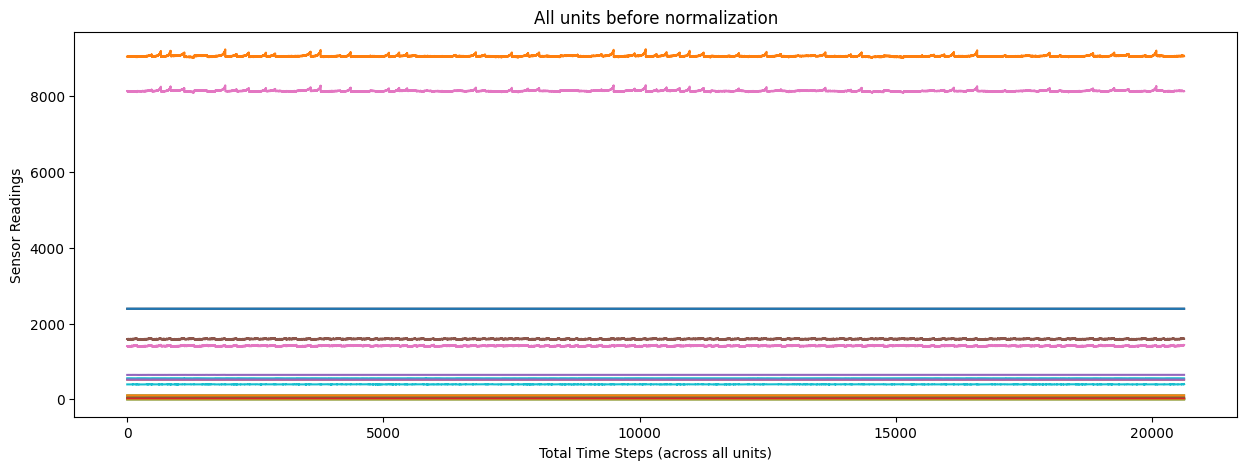

In [75]:
# Plot the input data for all units
plt.figure(figsize=(15, 5))
for col in name_list[2:]:
    plt.plot(data_train[col])
plt.title('All units before normalization')
plt.xlabel('Total Time Steps (across all units)')
plt.ylabel('Sensor Readings')
plt.show()


## Plot the data for a single unit

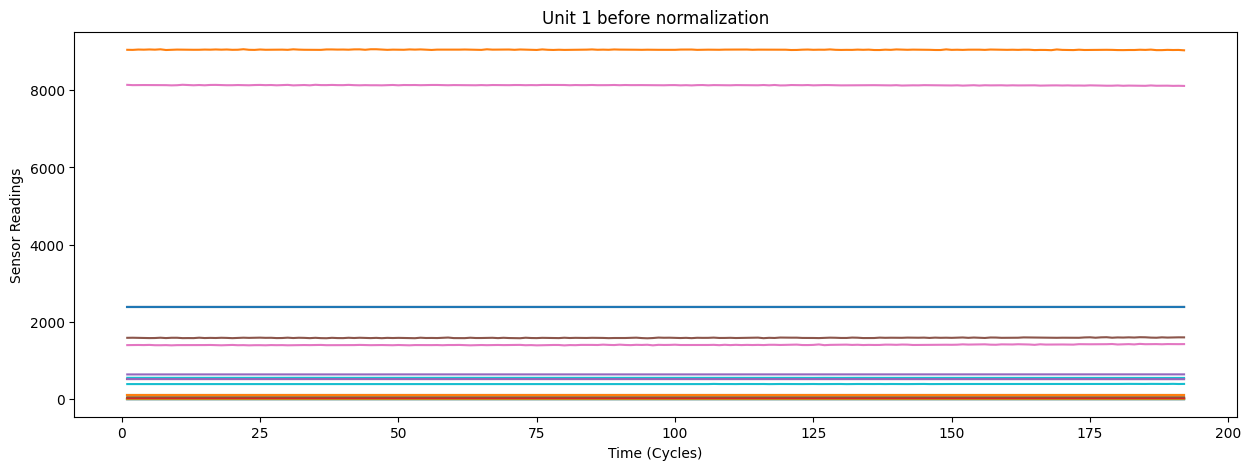

In [79]:
# Plot the input data for a single unit
plt.figure(figsize=(15, 5))
unit_1_data = data_train[data_train['unit'] == 1]
for col in name_list[2:]:
    plt.plot(unit_1_data['time'], unit_1_data[col])
plt.title('Unit 1 before normalization')
plt.xlabel('Time (Cycles)')
plt.ylabel('Sensor Readings')
plt.show()

## Drop irrelevant columns and normalize the training data

In [80]:
# Choose which columns of data you want to keep and which you want to drop.
# Training with everything works but might not be the best choice.
# Hint 1: Keep "unit" and "time" for now
# Hint 2: Remember to update name_list and n_columns
cols_to_drop = ['setting0', 'setting1', 'setting2', 'sensor0', 'sensor4', 'sensor5', 'sensor9', 'sensor15', 'sensor17', 'sensor18']
data_train = data_train.drop(cols_to_drop, axis=1)

name_list = data_train.columns
n_columns = len(data_train.columns)

In [82]:
# Normalization the training data
# Hint: It is a good idea to keep the data as a DataFrame, as the later code will
# assume this format.

data_train_scaled = data_train.copy()
scaler = StandardScaler()
data_train_scaled[name_list[2:]] = scaler.fit_transform(data_train[name_list[2:]])

In [88]:
data_train_scaled.shape

(20631, 16)

## Plot the normalized training data for all units

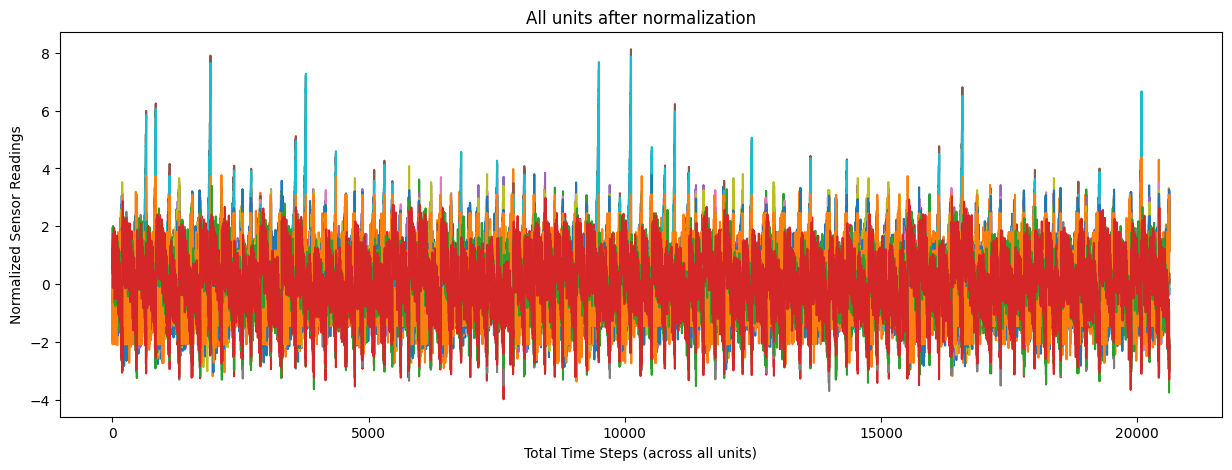

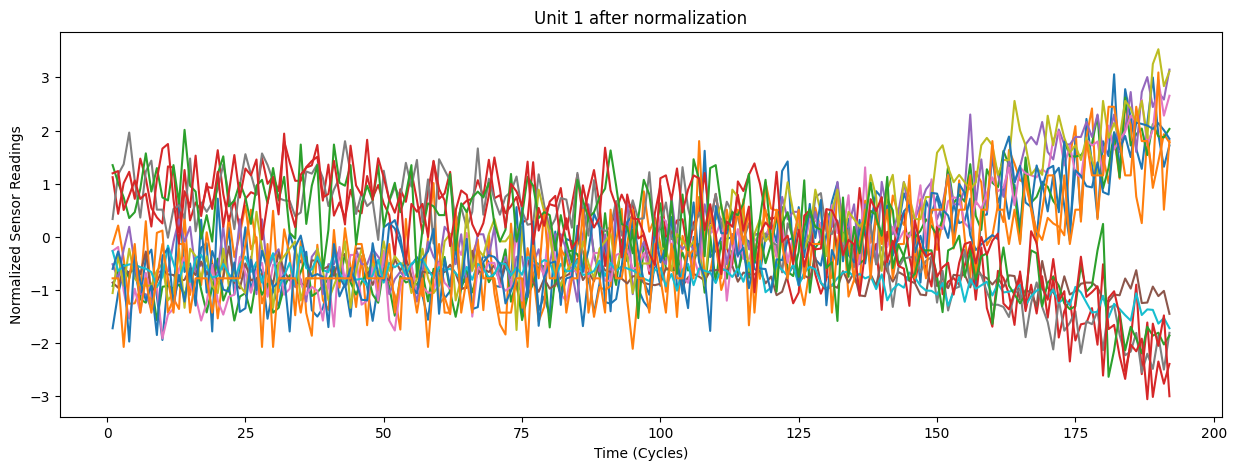

In [83]:
# Plot the normalized input data for all units and a single unit
plt.figure(figsize=(15, 5))
for col in name_list[2:]:
    plt.plot(data_train_scaled[col])
plt.title('All units after normalization')
plt.xlabel('Total Time Steps (across all units)')
plt.ylabel('Normalized Sensor Readings')
plt.show()

plt.figure(figsize=(15, 5))
unit_1_data_scaled = data_train_scaled[data_train_scaled['unit'] == 1]
for col in name_list[2:]:
    plt.plot(unit_1_data_scaled['time'], unit_1_data_scaled[col])
plt.title('Unit 1 after normalization')
plt.xlabel('Time (Cycles)')
plt.ylabel('Normalized Sensor Readings')
plt.show()

## Prepare the training data and labels

In [84]:
# Create multivariate time series with length n_past and calculate the RUL for
# each training dataset.
# You don't have to touch this

trainX_all = []
trainY_all = []

n_past = 30

# Loop over units:
for i_unit in np.arange(1,101):

  data_unit = data_train_scaled[data_train["unit"]==i_unit]

  max_time_unit = np.max(data_unit["time"])

  # Loop over times (cycles). We start at i_time=n_past because the window is n_past long:
  for i_time in np.arange(n_past, max_time_unit):
    X = data_unit.iloc[i_time-n_past:i_time][name_list[2:]]
    Y = max_time_unit - data_unit.iloc[i_time]["time"]

    trainX_all.append(X)
    trainY_all.append(Y)

  print(i_unit, end=" ")

trainX_all = np.array(trainX_all)
trainY_all = np.array(trainY_all)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

In [92]:
print(trainY_all.shape)
print(trainX_all.shape)

(17631,)
(17631, 30, 14)


Describe the loop above:

The loop transforms the continuous tabular data of each engine into discrete 30-cycle "snapshots" of historical sensor readings, paired exactly with how many cycles the engine actually had left to live at that very moment which is RUL (stored in Y).

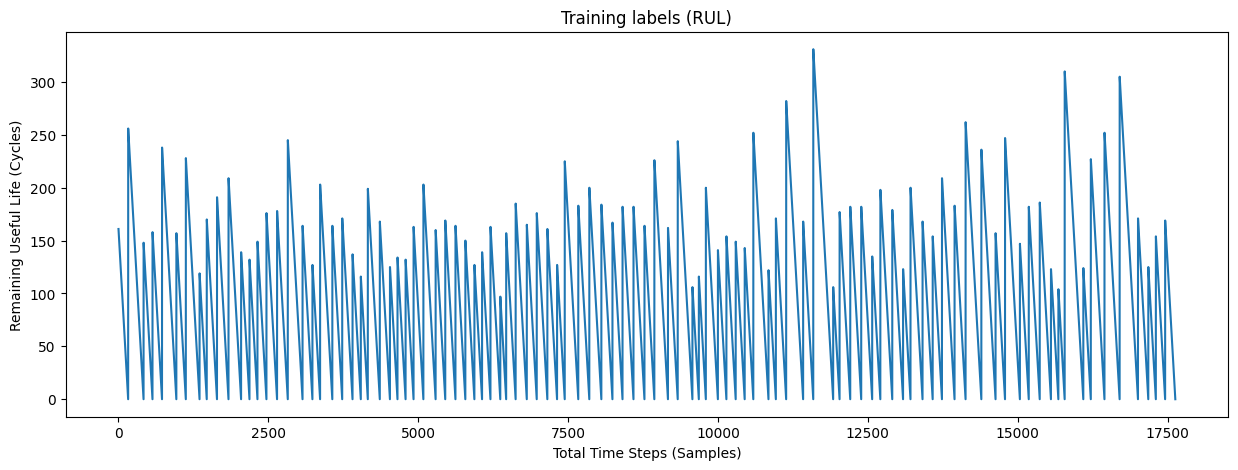

In [89]:
# Plot the labels of the training data set
plt.figure(figsize=(15, 5))
plt.plot(trainY_all)
plt.title('Training labels (RUL)')
plt.xlabel('Total Time Steps (Samples)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.show()

## Split the data into training and validation

In [93]:
# Split the data into a training and validation dataset (we will load a seperate test dataset later)
# Hint: Consider shuffling the data

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(trainX_all, trainY_all, test_size=0.2, random_state=42, shuffle=True)

## Define the RNN

In [94]:
# Former network
# Define the LSTM architecture

last_layer = 1

model = models.Sequential()
model.add(layers.Input(shape=(n_past, n_columns - 2)))
model.add(layers.LSTM(64, return_sequences=True))
model.add(layers.LSTM(32, return_sequences=False))
model.add(layers.Dense(32, activation='relu'))

model.add(layers.Dense(last_layer))

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,729 (131.75 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define the LSTM architecture from https://doi.org/10.3390/electronics10202453

last_layer = 1
model = models.Sequential()
model.add(layers.Input(shape=(n_past, n_columns - 2)))
# LSTM layer with 30 neurons
model.add(layers.LSTM(30, return_sequences=False))
# FC1 with 20 relu units
model.add(layers.Dense(20, activation='relu'))
# Dropout layer for regularization (rate not specified in table, 0.2 is a common default)
model.add(layers.Dropout(0.2))
# FC2 with 8 relu units
model.add(layers.Dense(8, activation='relu'))
# Output Layer with linear unit
model.add(layers.Dense(last_layer, activation='linear'))
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Implement LSTM from https://doi.org/10.3390/electronics10202453 which gives the better performance than GRU and s_RNN. We also provide another network which consists two LSTM layers which is better than the mentioned one. You will see the output from this network

## Train the RNN

In [95]:
# Define callbacks to save the best model during the training

# Options for EarlyStopping, ReduceLROnPlateau and ModelCheckpoint
callbacks = [
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1, min_lr=1e-5),
    keras.callbacks.EarlyStopping(patience=10, verbose=1, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor='val_loss', mode='min')
]
results = model.fit(X_train, y_train,
    epochs=50,
    batch_size=64,
    verbose=1,
    validation_data=(X_valid, y_valid),
    callbacks=callbacks)

Epoch 1/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 7928.2285 - val_loss: 3571.9260 - learning_rate: 0.0010
Epoch 2/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 2069.0361 - val_loss: 1231.6536 - learning_rate: 0.0010
Epoch 3/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 1090.7950 - val_loss: 932.9353 - learning_rate: 0.0010
Epoch 4/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 872.9528 - val_loss: 824.2288 - learning_rate: 0.0010
Epoch 5/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 787.2147 - val_loss: 742.0067 - learning_rate: 0.0010
Epoch 6/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 740.9965 - val_loss: 760.3627 - learning_rate: 0.0010
Epoch 7/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 683.4424 - val_loss: 694.2204 - learning_rate: 0.0010
Epoch 8/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 632.7903 - val_loss: 653.5187 - learning_rate: 0.0010
Epoch 9/50
221/221 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 587.9212 - val

## Plot the results and Evaluate the performance

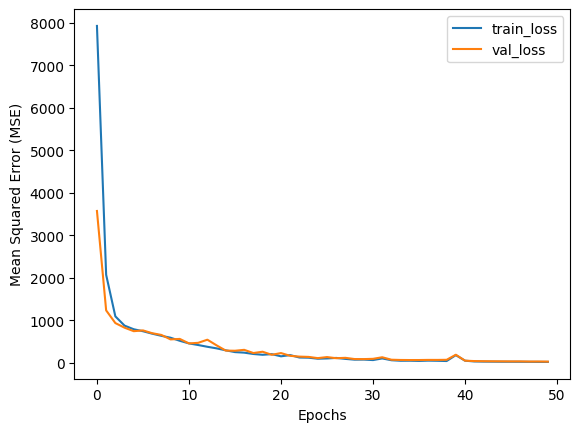

In [96]:
# Plotting training loss and validation loss
plt.figure()
plt.plot(results.history['loss'], label='train_loss')
plt.plot(results.history['val_loss'], label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

The losses are large because of the value of data?????

In [97]:
# Predict on the training dataset
pred_train = model.predict(trainX_all)

# You can load the best model of your callback option via
model.load_weights("best_model.keras")

551/551 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


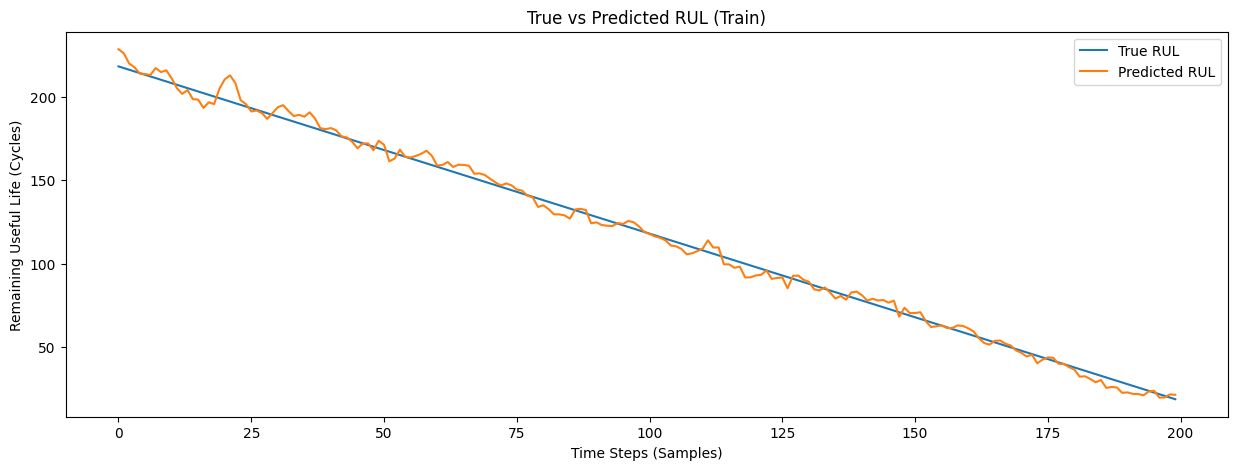

In [99]:
# Plot the true RUL and the network prediction for the training data
plt.figure(figsize=(15, 5))
plt.plot(trainY_all[200:400], label='True RUL')
plt.plot(pred_train[200:400], label='Predicted RUL')
plt.title('True vs Predicted RUL (Train)')
plt.xlabel('Time Steps (Samples)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.show()

## Evaluate on the test data:

We load the test data and labels from two different files, `test_FD001.txt` and `RUL_FD001.txt`, which contain data for 100 engines (different from the training data). The test data is formatted sligthly differently from the training data. Instead of gettting full sequences from start of an engines life to its failure, we get shorter sequences of varying length for the 100 engines. The file `RUL_FD001.txt` then contains the time from the end of the sequence to the engine's failure, i.e., the RUL. In the code below we create 100 test datasets by cutting the test squences to the n_past last datapoints.

You should drop the same coloumns as with the training data and implement the same normalization.

In [100]:
# Load test data set and labels
data_test = pd.read_csv('CMAPSSData/test_FD001.txt', delimiter=' ', header=None, usecols=range(26))
labels_test = pd.read_csv('CMAPSSData/RUL_FD001.txt', delimiter=' ', header=None, usecols=[0])

name_list = ['unit', 'time', 'setting0', 'setting1', 'setting2']

number_of_sensors = 21
for i in range(number_of_sensors):
  name_list.append('sensor'+str(i))

data_test.columns = name_list

labels_test.columns = ['RUL']


# Drop the unneccesary columns
data_test = data_test.drop(cols_to_drop, axis=1, errors='ignore')

# IMPORTANT: Update name_list so it no longer contains the dropped columns!
name_list = data_test.columns

# Normalization of the training data with the same scaling as the training data
data_test_scaled = data_test.copy()
data_test_scaled[name_list[2:]] = scaler.transform(data_test[name_list[2:]])



# Create multivariate time series with length n_past for each test engine
# You don't have to touch this

testX = []
testY = []

# Loop over units:
for i_unit in np.arange(1,101):

  data_unit = data_test_scaled[data_test_scaled["unit"]==i_unit]

  X = data_unit.iloc[-n_past:][name_list[2:]]
  Y = labels_test.iloc[i_unit-1]["RUL"]

  testX.append(X)
  testY.append(Y)

  print(i_unit, end=" ")

testX = np.array(testX)
testY = np.array(testY)

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 

In [101]:
# Predict on the test datasets
pred_test = model.predict(testX)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [106]:
print(testX.shape)
print(testY.shape)

(100, 30, 14)
(100,)


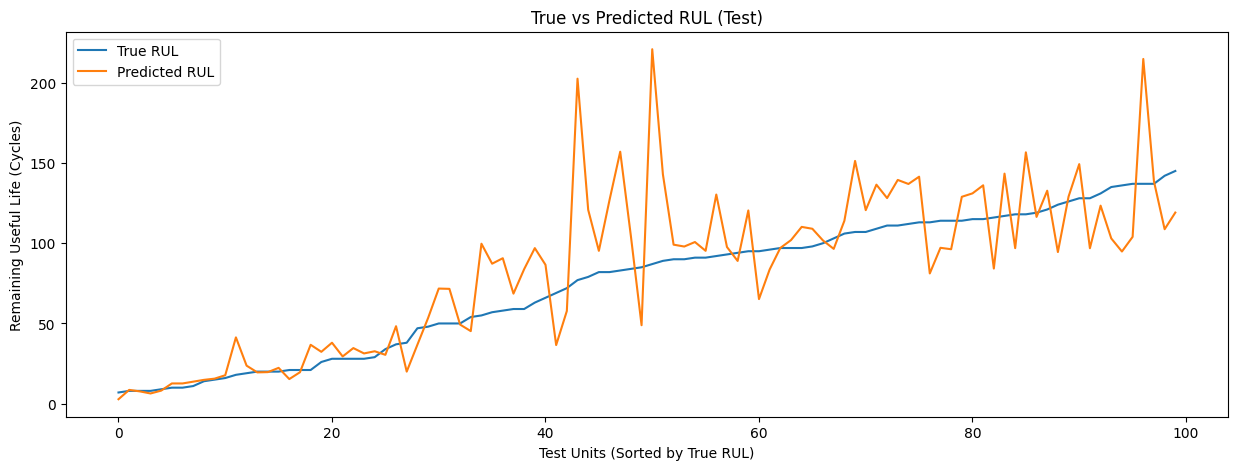

In [105]:
# Plot the prediction and the true values for each test unit
# Hint: Depending on how you plot it, it may be easier to compare the true
# values and the predicted values if you order them in a smart way.
indices = np.argsort(testY)
plt.figure(figsize=(15, 5))
plt.plot(testY[indices], label='True RUL')
plt.plot(pred_test[indices], label='Predicted RUL')
plt.title('True vs Predicted RUL (Test)')
plt.xlabel('Test Units (Sorted by True RUL)')
plt.ylabel('Remaining Useful Life (Cycles)')
plt.legend()
plt.show()

In [107]:
# Calculate the MSE and MAE of the training, validation and test predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error
pred_valid = model.predict(X_valid)
print("Train MSE:", mean_squared_error(trainY_all, pred_train))
print("Train MAE:", mean_absolute_error(trainY_all, pred_train))
print("Valid MSE:", mean_squared_error(y_valid, pred_valid))
print("Valid MAE:", mean_absolute_error(y_valid, pred_valid))
print("Test MSE:", mean_squared_error(testY, pred_test))
print("Test MAE:", mean_absolute_error(testY, pred_test))

111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Train MSE: 17.522618299023467
Train MAE: 3.147673895724017
Valid MSE: 25.701796054783365
Valid MAE: 3.7876201949175
Test MSE: 875.8903198242188
Test MAE: 19.562763214111328


The final loss: How far off our cycle predictions are from reality where lower values mean closer prediction. For the tess loss ~ 19, it means that the network's prediction is off by 19 cycles from the exact moment of failure.

## (optional) Recommend Maintenance

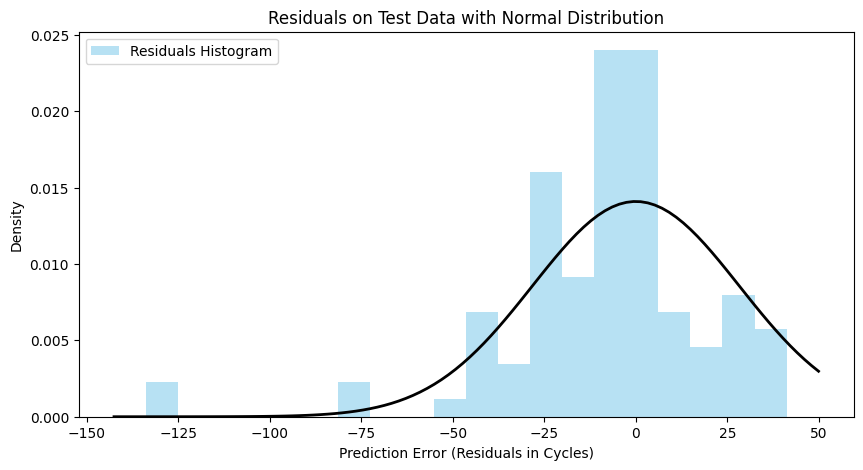

Standard deviation of residuals: 28.318854347291413


In [117]:
from scipy.stats import norm

# Plot the residuals in a histogram with a Normal Distribution overlay
residuals = testY - pred_test.flatten()

plt.figure(figsize=(10, 5))
# Note: density=True is required so the histogram y-axis matches the probability density of the normal curve
plt.hist(residuals, bins=20, density=True, alpha=0.6, color='skyblue', label='Residuals Histogram')

# Calculate mean and standard deviation
mean_res = np.mean(residuals)
std_residuals = np.std(residuals)

# Generate an x-axis range based on the plot limits
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

# Create the normal probability density function (PDF) curve
p = norm.pdf(x, 0, std_residuals)

# Plot the normal curve
plt.plot(x, p, 'k', linewidth=2)

plt.title('Residuals on Test Data with Normal Distribution')
plt.xlabel('Prediction Error (Residuals in Cycles)')
plt.ylabel('Density')
plt.legend()
plt.show()

print('Standard deviation of residuals:', std_residuals)


- If the residual is positive, the engine survived longer than we predicted (safe).
- If the residual is negative, the engine failed earlier than we predicted (dangerous).

In [116]:
# Answer to question 6:
# If we want to be 95% sure that engine has at least 20 cycles to go:
# Z for 95% one-sided confidence interval is 1.645
# We want: True RUL > 20 with 95% prob.
# True RUL = Predicted RUL + Residual
# Since True RUL > 20 => Predicted RUL + Residual > 20
# The 5th percentile of residuals is roughly -1.645 * std
# Predicted RUL - 1.645 * std > 20  =>  Predicted RUL > 20 + 1.645 * std

output_for_maint = 20 + 1.645 * std_residuals
print('The engine should be recomended for maintainance with an output below: ', output_for_maint)


The engine should be recomended for maintainance with an output below:  66.58451540129437
